In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

# Change this to one actual image path from your dataset
IMAGE_PATH = Path(
    r"H:\UOR\7th sem\Computer Vision\final_dataset"
)

# Find one PNG image automatically
all_images = list(IMAGE_PATH.rglob("*.png"))

print("Total PNG images found:", len(all_images))

sample_image_path = all_images[2]

print("Using image:")
print(sample_image_path)

image_bgr = cv2.imread(str(sample_image_path))

print("Image loaded:", image_bgr is not None)

if image_bgr is not None:
    print("Original shape:", image_bgr.shape)

Total PNG images found: 584
Using image:
H:\UOR\7th sem\Computer Vision\final_dataset\class_1_forged\600dpi-036.png
Image loaded: True
Original shape: (7013, 4962, 3)


In [3]:
DISPLAY_WIDTH = 900

h, w = image_bgr.shape[:2]

scale = DISPLAY_WIDTH / w
new_h = int(h * scale)

image_resized = cv2.resize(
    image_bgr,
    (DISPLAY_WIDTH, new_h)
)

print("Resized shape:", image_resized.shape)

Resized shape: (1272, 900, 3)


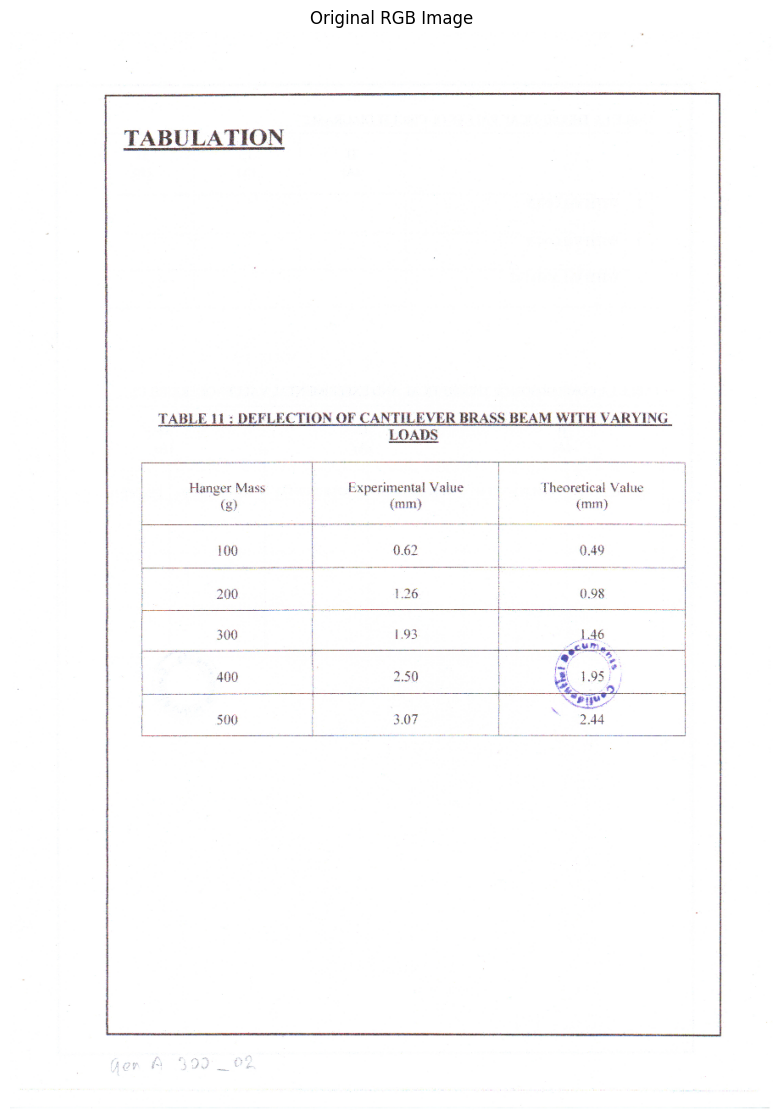

In [4]:
image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 14))
plt.imshow(image_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()


In [5]:
image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)

print("HSV shape:", image_hsv.shape)

HSV shape: (1272, 900, 3)


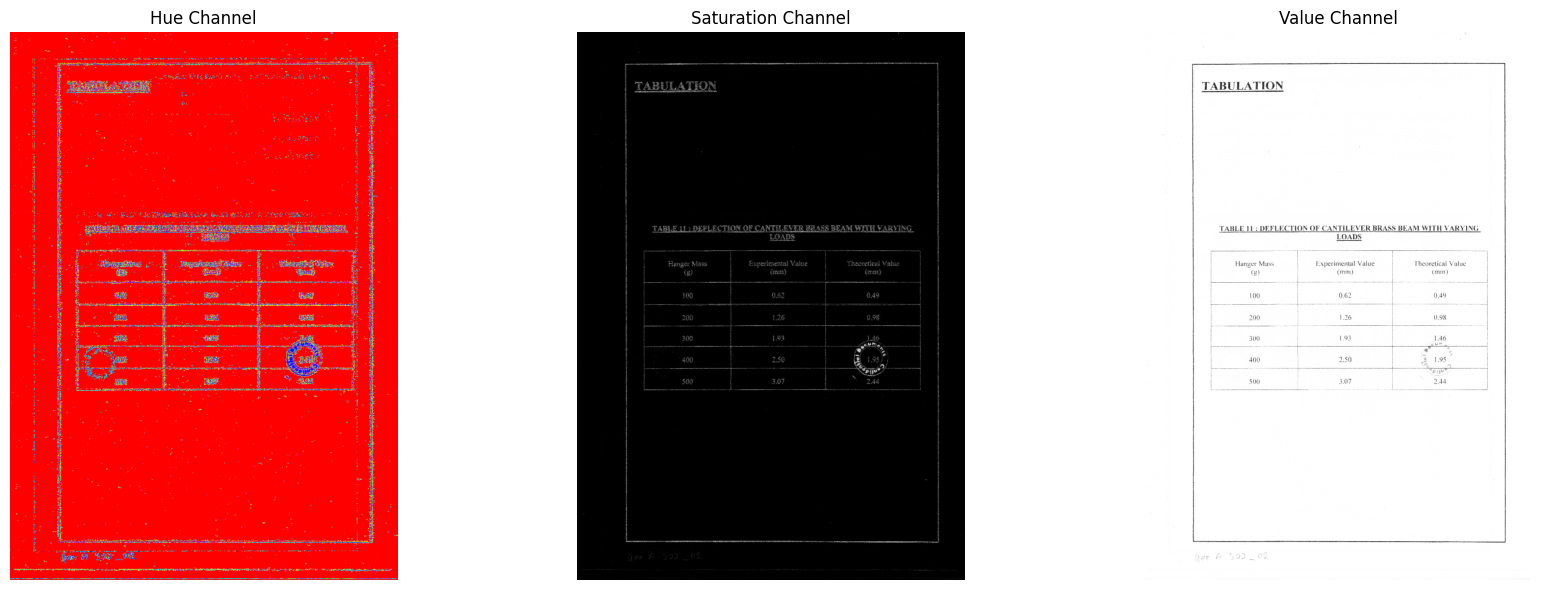

In [6]:
h_channel = image_hsv[:, :, 0]
s_channel = image_hsv[:, :, 1]
v_channel = image_hsv[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(h_channel, cmap="hsv")
axes[0].set_title("Hue Channel")
axes[0].axis("off")

axes[1].imshow(s_channel, cmap="gray")
axes[1].set_title("Saturation Channel")
axes[1].axis("off")

axes[2].imshow(v_channel, cmap="gray")
axes[2].set_title("Value Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

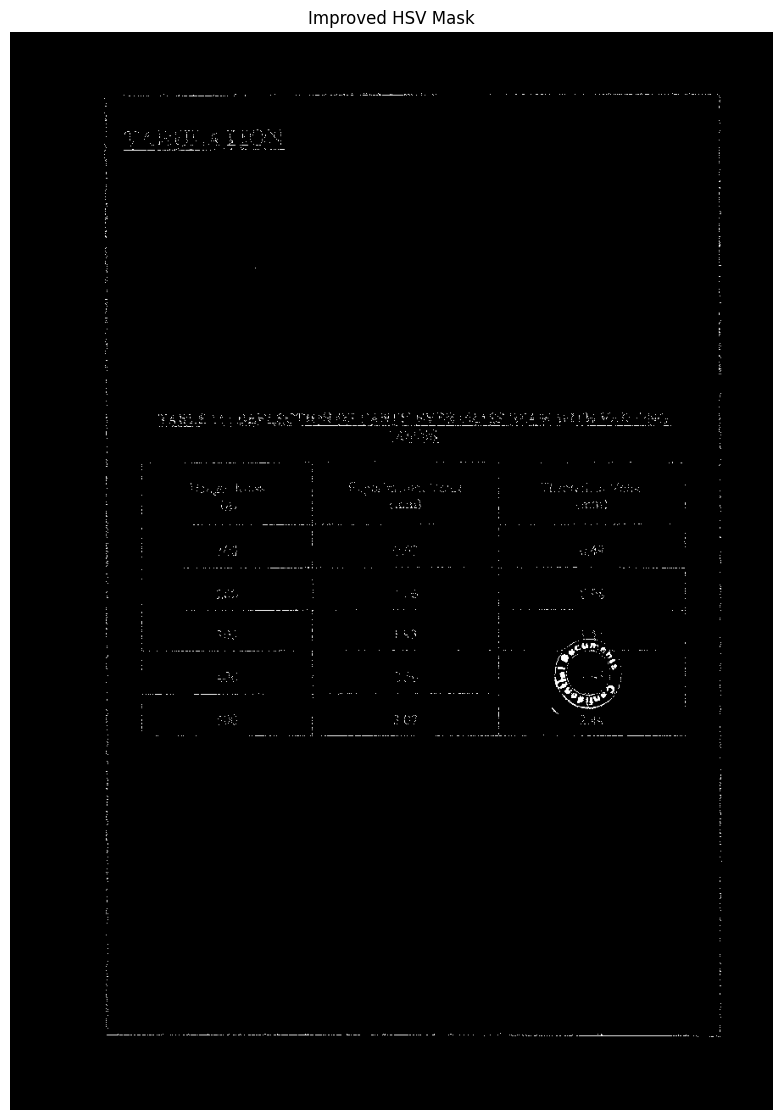

In [7]:
# Improved blue/violet threshold
lower_stamp = np.array([95, 60, 40])
upper_stamp = np.array([165, 255, 255])

mask = cv2.inRange(
    image_hsv,
    lower_stamp,
    upper_stamp
)

plt.figure(figsize=(10, 14))
plt.imshow(mask, cmap="gray")
plt.title("Improved HSV Mask")
plt.axis("off")
plt.show()

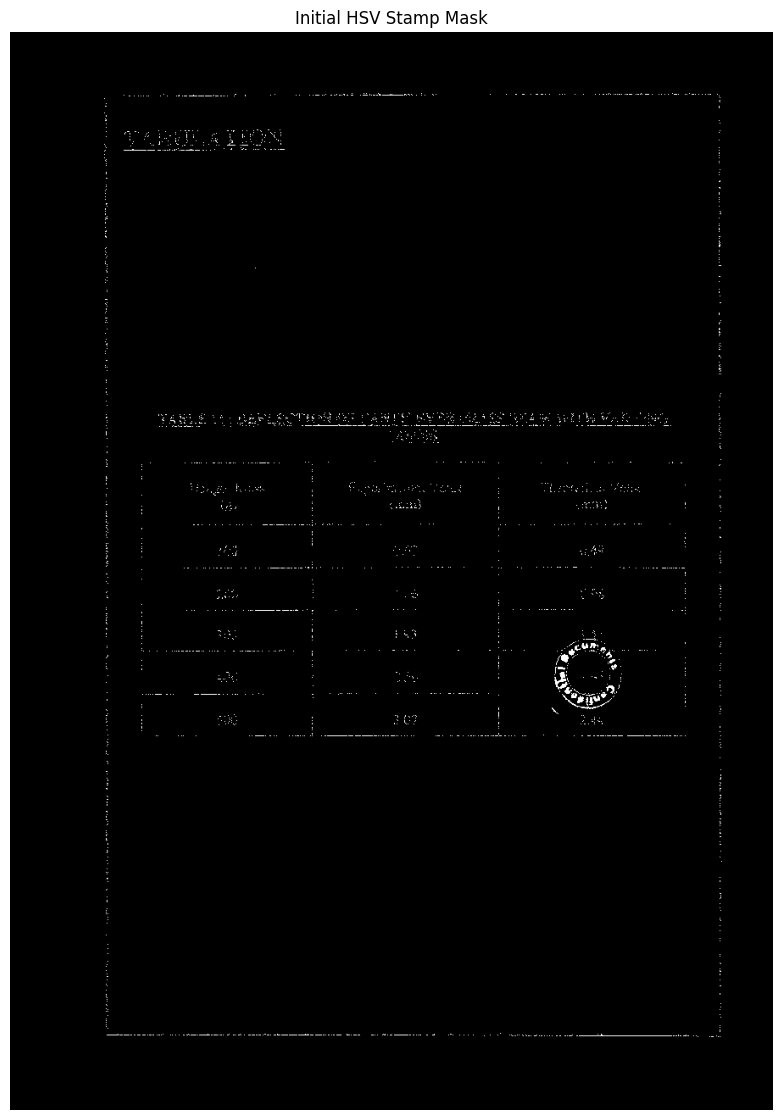

In [8]:
plt.figure(figsize=(10, 14))
plt.imshow(mask, cmap="gray")
plt.title("Initial HSV Stamp Mask")
plt.axis("off")
plt.show()

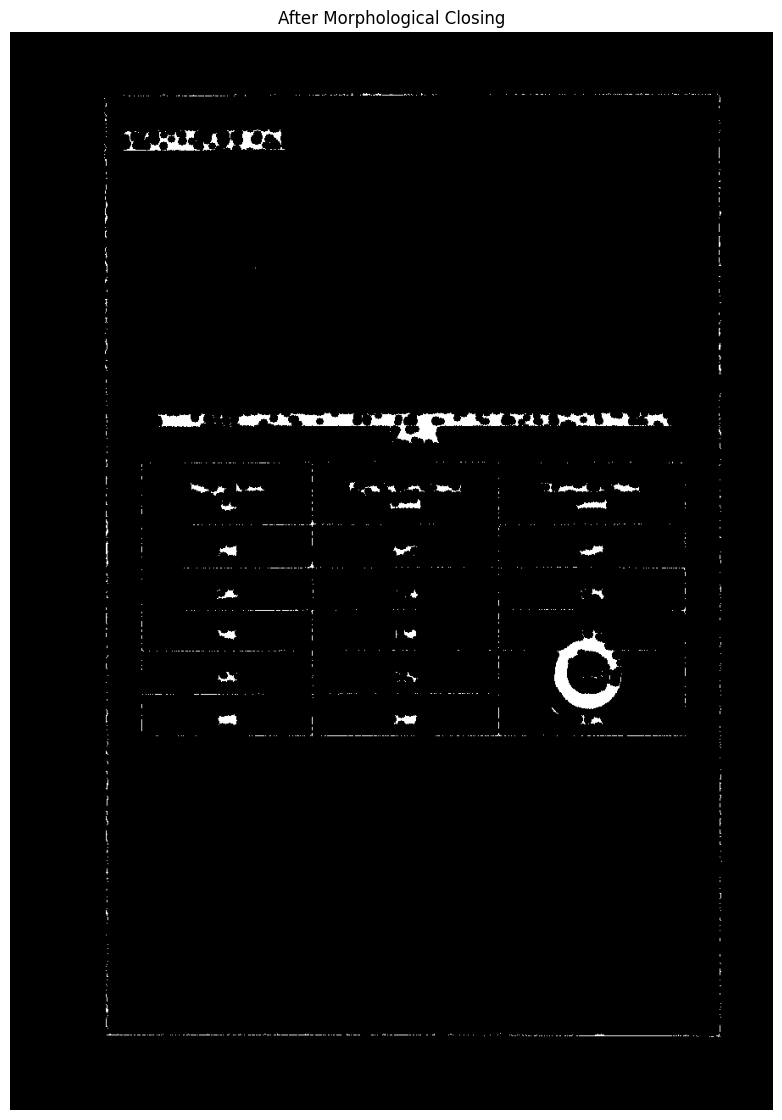

In [9]:
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

mask_closed = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel_close
)

plt.figure(figsize=(10, 14))
plt.imshow(mask_closed, cmap="gray")
plt.title("After Morphological Closing")
plt.axis("off")
plt.show()

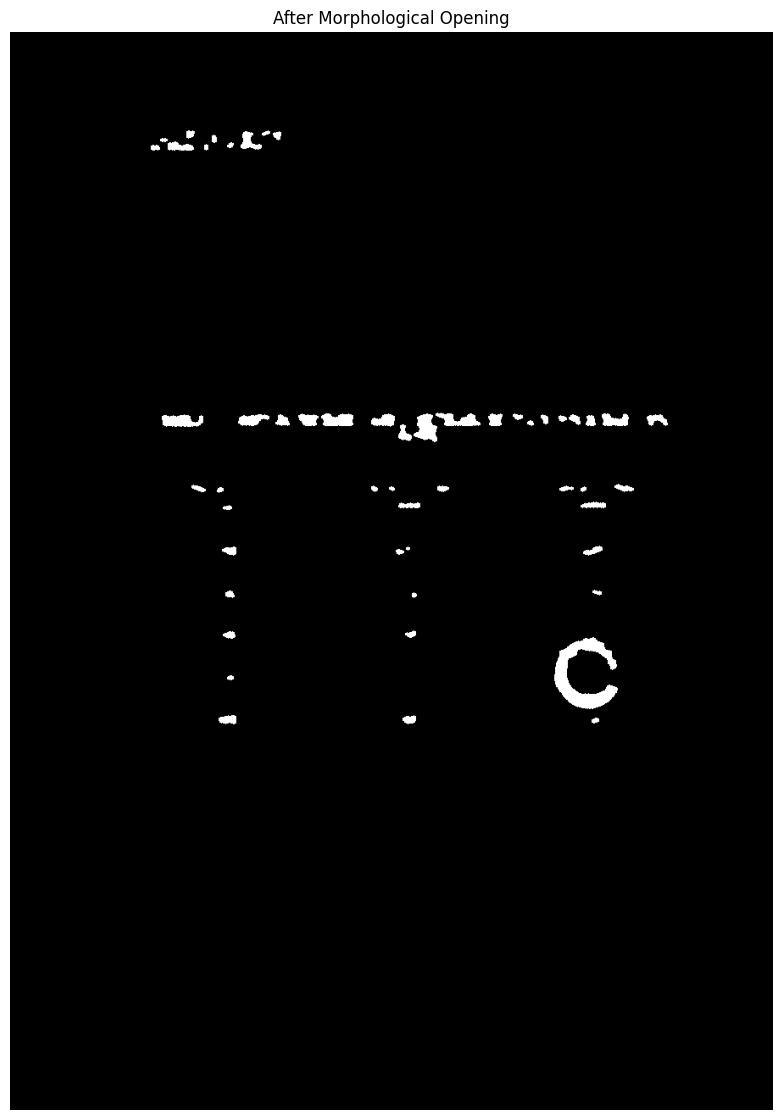

In [10]:
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

mask_opened = cv2.morphologyEx(
    mask_closed,
    cv2.MORPH_OPEN,
    kernel_open
)

plt.figure(figsize=(10, 14))
plt.imshow(mask_opened, cmap="gray")
plt.title("After Morphological Opening")
plt.axis("off")
plt.show()

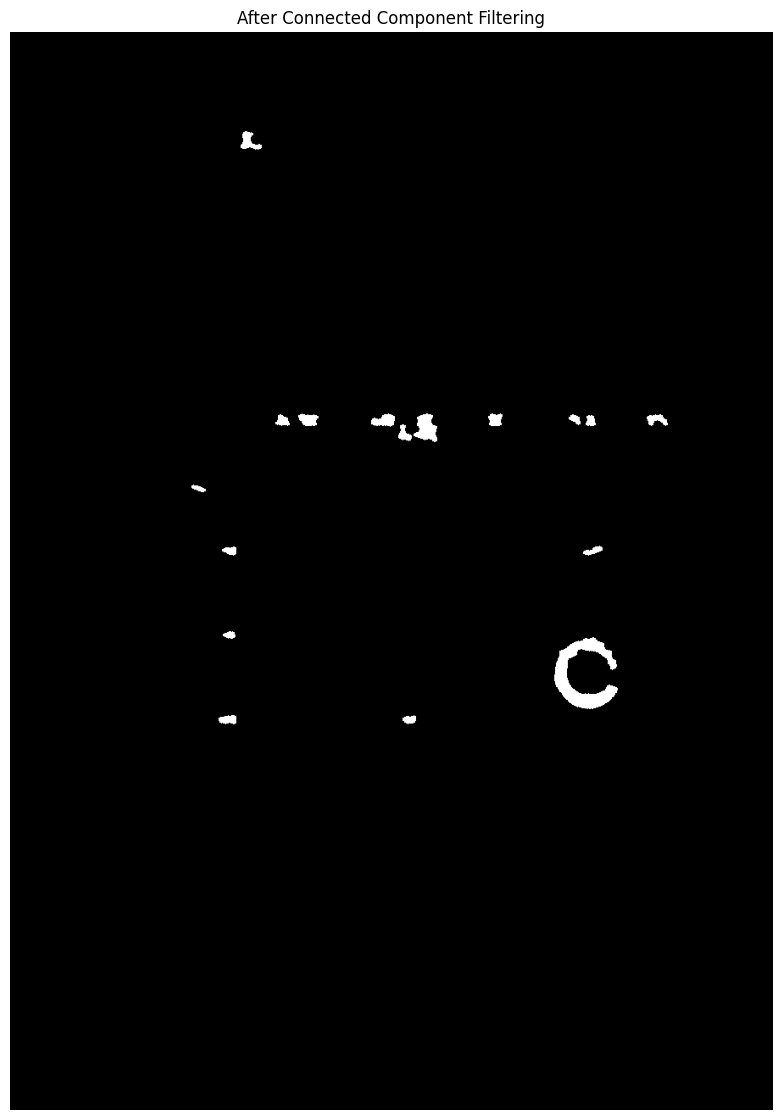

In [11]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_opened, connectivity=8)

filtered_mask = np.zeros_like(mask_opened)

for i in range(1, num_labels):  # skip background
    x, y, w, h, area = stats[i]

    if area < 80:
        continue

    aspect_ratio = w / h if h > 0 else 0

    # Keep compact/circular-ish regions, remove long text strokes
    if 0.5 <= aspect_ratio <= 2.0:
        filtered_mask[labels == i] = 255

plt.figure(figsize=(10, 14))
plt.imshow(filtered_mask, cmap="gray")
plt.title("After Connected Component Filtering")
plt.axis("off")
plt.show()

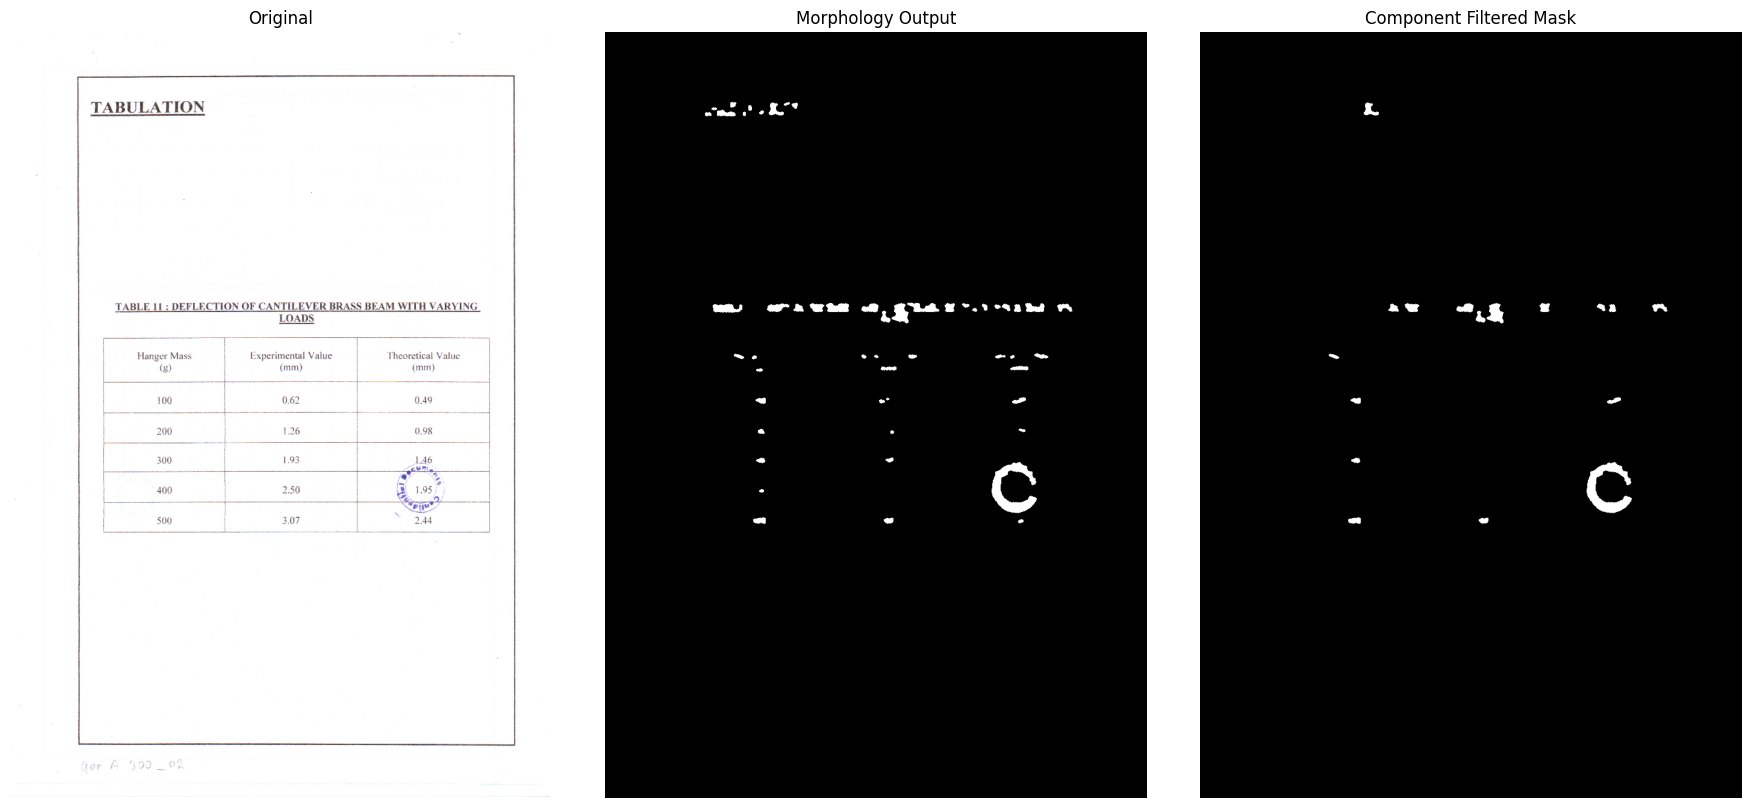

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_opened, cmap="gray")
axes[1].set_title("Morphology Output")
axes[1].axis("off")

axes[2].imshow(filtered_mask, cmap="gray")
axes[2].set_title("Component Filtered Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()